# MLP v2: arquitecturas, curvas por época y gráficos diagnósticos

Compara tres variantes con el mismo esquema temporal del ridge (entrenar con años < t, probar en t):

| Variante | Qué es |
|---|---|
| `mlp` | MLP plano: 2445 SNPs → 256 → cabeza (GELU, dropout) |
| `resnet` | Proyección + bloques residuales con LayerNorm (más profundo y estable) |
| `resnet+parents` | Igual, más un embedding de los dos padres de la familia (pedigrí conocido de antemano) |

La idea de `resnet+parents`: el ridge ya mostró que la señal **entre familias** viene de padres compartidos; el genotipo por sí solo la captura a medias. Los padres que no aparecen en el entrenamiento reciben embedding cero, y durante el entrenamiento se ocultan al azar para que la red aprenda a funcionar sin ellos.

**Entrenamiento:** por épocas y mini-batches (`batch_size`), con AdamW y early stopping sobre el año t-1. Se registran pérdida de entrenamiento y correlación de validación en cada época.

**Prerrequisitos:** `build_dataset.py` y `ridge_temporal.py` ya ejecutados. Empieza con `QUICK_RUN = True` y luego ponlo en `False`.

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "DIGITALTOOL").is_dir():
            return d
    raise FileNotFoundError("Run the notebook from inside the Hackolombia repo")


BASE_DIR = find_root(Path.cwd().resolve())
DATA_DIR = BASE_DIR / "DIGITALTOOL" / "data" / "processed" / "prediction"
sys.path.insert(0, str(BASE_DIR / "DIGITALTOOL" / "src" / "03_prediction"))
from ridge_temporal import pearson, metrics  # same metrics as the ridge baseline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__)

device: cpu | torch 2.14.0+cu130


In [2]:
QUICK_RUN = False   # True: test year 2008 only, 1 seed, few epochs (smoke test)

BASE = dict(
    max_snp_na=0.20,
    test_years=[2008] if QUICK_RUN else [2006, 2007, 2008],
    arch="mlp",              # "mlp" | "resnet"
    width=256,               # cost is dominated by the first layer (2445 x width)
    n_blocks=2,              # residual blocks (resnet only)
    dropout=0.3,
    input_dropout=0.1,
    use_parents=False,
    parent_dim=16,
    parent_index_dropout=0.2,  # prob. of hiding a line's parents during training
    lr=1e-3,
    weight_decay=1e-2,
    batch_size=512,
    max_epochs=5 if QUICK_RUN else 40,
    patience=5,
    n_seeds=1 if QUICK_RUN else 3,
    use_weights=True,        # weight lines by number of observations
    weight_cap=10,
)
VARIANTS = {
    "mlp": {},
    "resnet": {"arch": "resnet"},
    "resnet+parents": {"arch": "resnet", "use_parents": True},
}
PLOT_YEAR = BASE["test_years"][-1]

## 1. Datos

In [3]:
X_raw = np.load(DATA_DIR / "X.npy", mmap_mode="r")
lines = pd.read_parquet(DATA_DIR / "lines.parquet")

keep = np.where(np.isnan(X_raw).mean(axis=0) < BASE["max_snp_na"])[0]
X = np.asarray(X_raw[:, keep], dtype=np.float32)
print(f"{X.shape[0]} lines, {X.shape[1]}/{X_raw.shape[1]} SNPs kept")

# Mean imputation + standardization using pre-2008 lines only (2008 is never used for fitting)
years = lines["YEAR"].to_numpy()
pre = years < 2008
mu = np.nanmean(X[pre], axis=0)
for j in range(X.shape[1]):
    col = X[:, j]
    col[np.isnan(col)] = mu[j]
X -= mu
sd = X[pre].std(axis=0)
sd[sd < 1e-6] = 1.0
X /= sd
print("NaN left:", int(np.isnan(X).sum()))

68421 lines, 2445/2911 SNPs kept
NaN left: 0


In [4]:
# Target: BLUE centered by year, scaled by the pre-2008 sd
centered = lines["BLUE"] - lines.groupby("YEAR")["BLUE"].transform("mean")
y_sd = float(centered[pre].std())
y = (centered / y_sd).to_numpy(dtype=np.float32)
pops = lines["POP"].to_numpy()

w = np.clip(lines["N_OBS"].to_numpy(dtype=np.float32), 1, BASE["weight_cap"])
w = (w / w.mean()).astype(np.float32)
X_t = torch.from_numpy(X)

# Parent ids per line (0 is reserved for "unknown / unseen in training")
par_tab = pd.read_csv(DATA_DIR / "parents.csv").set_index("POP")
pid = {p: i + 1 for i, p in enumerate(pd.unique(par_tab[["PARENT1", "PARENT2"]].to_numpy().ravel()))}
parent_idx = np.stack([lines["POP"].map(par_tab["PARENT1"]).map(pid),
                       lines["POP"].map(par_tab["PARENT2"]).map(pid)], axis=1)
parent_idx = np.nan_to_num(parent_idx.astype(float)).astype(np.int64)
N_PARENTS = len(pid)

seen_pre = np.unique(parent_idx[pre])
share = np.isin(parent_idx[years == 2008], seen_pre).any(axis=1).mean()
print(f"{N_PARENTS} distinct parents | 2008 lines with at least one parent seen before 2008: {share:.0%}")

260 distinct parents | 2008 lines with at least one parent seen before 2008: 85%


## 2. Modelo y entrenamiento por épocas y batches

En cada época se recorren todas las líneas de entrenamiento en mini-batches barajados; tras cada época se mide la validación. `train_model` devuelve el historial (pérdida de entrenamiento, r global y r dentro de familia en validación).

In [5]:
class ResBlock(nn.Module):
    def __init__(self, d, p):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d), nn.GELU(), nn.Dropout(p), nn.Linear(d, d))

    def forward(self, x):
        return x + self.net(x)


class GenoNet(nn.Module):
    def __init__(self, cfg, n_snps):
        super().__init__()
        wd, dr = cfg["width"], cfg["dropout"]
        self.drop_in = nn.Dropout(cfg["input_dropout"])
        self.proj = nn.Sequential(nn.Linear(n_snps, wd), nn.GELU(), nn.Dropout(dr))
        if cfg["arch"] == "resnet":
            self.body = nn.Sequential(*[ResBlock(wd, dr) for _ in range(cfg["n_blocks"])])
        else:
            self.body = nn.Identity()
        self.use_parents = cfg["use_parents"]
        head_in = wd
        if self.use_parents:
            self.emb = nn.Embedding(N_PARENTS + 1, cfg["parent_dim"], padding_idx=0)
            head_in += cfg["parent_dim"]
        self.head = nn.Sequential(nn.LayerNorm(head_in), nn.Linear(head_in, 64), nn.GELU(), nn.Linear(64, 1))
        self.seen = np.array([], dtype=np.int64)

    def forward(self, x, par):
        h = self.body(self.proj(self.drop_in(x)))
        if self.use_parents:
            h = torch.cat([h, self.emb(par).sum(dim=1)], dim=1)
        return self.head(h).squeeze(1)


def mask_parents(idx, seen):
    p = parent_idx[idx]
    return np.where(np.isin(p, seen), p, 0)


@torch.no_grad()
def predict(model, idx):
    model.eval()
    par = torch.from_numpy(mask_parents(idx, model.seen))
    Xq = X_t[torch.from_numpy(idx)]
    out = [model(Xq[i:i + 4096].to(DEVICE), par[i:i + 4096].to(DEVICE)).cpu() for i in range(0, len(idx), 4096)]
    return torch.cat(out).numpy()


def train_model(cfg, tr_idx, val_idx=None, epochs=None, seed=0):
    """Train on lines tr_idx, epoch by epoch over shuffled mini-batches.
    With val_idx: early-stop on validation Pearson r (returns the best epoch).
    With epochs: train exactly that many epochs."""
    torch.manual_seed(seed)
    model = GenoNet(cfg, X.shape[1]).to(DEVICE)
    model.seen = np.unique(parent_idx[tr_idx])
    model.seen = model.seen[model.seen > 0]

    Xtr = X_t[torch.from_numpy(tr_idx)].to(DEVICE)
    ytr = torch.from_numpy(y[tr_idx]).to(DEVICE)
    wtr = torch.from_numpy(w[tr_idx]).to(DEVICE)
    ptr = torch.from_numpy(parent_idx[tr_idx]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    bs, n = cfg["batch_size"], len(tr_idx)
    max_ep = epochs if epochs is not None else cfg["max_epochs"]
    best_r, best_ep, hist = -np.inf, 1, []

    for ep in range(1, max_ep + 1):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        loss_sum = 0.0
        for i in range(0, n, bs):
            b = perm[i:i + bs]
            pb = ptr[b]
            if model.use_parents:
                hide = torch.rand(len(b), 1, device=DEVICE) < cfg["parent_index_dropout"]
                pb = pb.masked_fill(hide, 0)
            loss = (wtr[b] * (model(Xtr[b], pb) - ytr[b]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_sum += loss.item() * len(b)
        row = {"epoch": ep, "train_loss": loss_sum / n}
        if val_idx is not None:
            pv = predict(model, val_idx)
            m = metrics(pv, y[val_idx].astype(np.float64), pops[val_idx])
            row.update(val_r_all=m["r_all"], val_r_within=m["r_within"])
            if m["r_all"] > best_r:
                best_r, best_ep = m["r_all"], ep
        hist.append(row)
        if val_idx is not None and ep - best_ep >= cfg["patience"]:
            break
    return model, best_ep, pd.DataFrame(hist)

## 3. Ventana creciente para cada variante

Para cada año de prueba t: (1) por semilla, entrenar con años < t-1 y validar en t-1 (aquí salen las curvas por época y se elige el número de épocas); (2) reentrenar con años < t y promediar las semillas. El año t no decide nada.

In [6]:
def run_variant(name, cfg):
    rows, curves, preds = [], [], {}
    for t in cfg["test_years"]:
        t0 = time.time()
        tr_prev = np.where(years < t - 1)[0]
        val = np.where(years == t - 1)[0]
        tr_all = np.where(years < t)[0]
        te = np.where(years == t)[0]

        best_eps = []
        for s in range(cfg["n_seeds"]):
            _, ep, hist = train_model(cfg, tr_prev, val_idx=val, seed=s)
            best_eps.append(ep)
            curves.append(hist.assign(variant=name, test_year=t, seed=s))
        n_ep = int(np.median(best_eps))

        seed_preds = []
        for s in range(cfg["n_seeds"]):
            model, _, _ = train_model(cfg, tr_all, epochs=n_ep, seed=100 + s)
            seed_preds.append(predict(model, te))
        pred = np.mean(seed_preds, axis=0)

        res = metrics(pred, y[te].astype(np.float64), pops[te])
        res.update(variant=name, test_year=t, n_epochs=n_ep, n_train=len(tr_all), n_test=len(te))
        rows.append(res)
        preds[t] = pd.DataFrame({"LINE_ID": lines["LINE_ID"].to_numpy()[te], "POP": pops[te],
                                 "BLUE": lines["BLUE"].to_numpy()[te], "y": y[te], "pred": pred})
        print(f"[{name}] test {t}: epochs={n_ep} (per seed {best_eps}) | r_all={res['r_all']:.3f} "
              f"r_within={res['r_within']:.3f} | {time.time() - t0:.0f}s")
    return pd.DataFrame(rows), pd.concat(curves, ignore_index=True), preds


results, curves, preds = [], [], {}
for name, over in VARIANTS.items():
    r, c, p = run_variant(name, {**BASE, **over})
    results.append(r); curves.append(c); preds[name] = p
results = pd.concat(results, ignore_index=True)
curves = pd.concat(curves, ignore_index=True)

[mlp] test 2006: epochs=2 (per seed [2, 23, 2]) | r_all=0.225 r_within=0.180 | 76s
[mlp] test 2007: epochs=8 (per seed [6, 25, 8]) | r_all=0.063 r_within=0.196 | 157s
[mlp] test 2008: epochs=2 (per seed [10, 2, 2]) | r_all=0.145 r_within=0.128 | 81s
[resnet] test 2006: epochs=2 (per seed [2, 3, 2]) | r_all=0.247 r_within=0.171 | 58s
[resnet] test 2007: epochs=7 (per seed [7, 7, 10]) | r_all=0.085 r_within=0.187 | 163s
[resnet] test 2008: epochs=5 (per seed [8, 5, 1]) | r_all=0.136 r_within=0.126 | 142s
[resnet+parents] test 2006: epochs=2 (per seed [2, 20, 1]) | r_all=0.237 r_within=0.170 | 94s
[resnet+parents] test 2007: epochs=2 (per seed [2, 3, 2]) | r_all=0.070 r_within=0.185 | 88s
[resnet+parents] test 2008: epochs=5 (per seed [1, 5, 6]) | r_all=0.174 r_within=0.126 | 150s


## 4. Gráficos que sí informan

1. **Curvas por época:** ¿el modelo aprende, se sobreajusta, cuándo conviene parar? Si la r de validación sube y se aplana mientras la pérdida sigue bajando, hay sobreajuste.
2. **Métricas por año contra el ridge:** ¿la red aporta algo sostenido o solo en un año?
3. **Curva de respuesta a la selección:** cuánto rinde de más lo que seleccionas al quedarte con el top x%. Es la métrica de negocio; la línea "oráculo" es el techo y el azar es 0.
4. **r dentro de cada familia:** ¿el modelo sirve en todas las familias o solo en unas pocas?
5. **Predicho vs observado, y por familia:** separa lo que el modelo acierta entre familias de lo que acierta dentro de ellas.

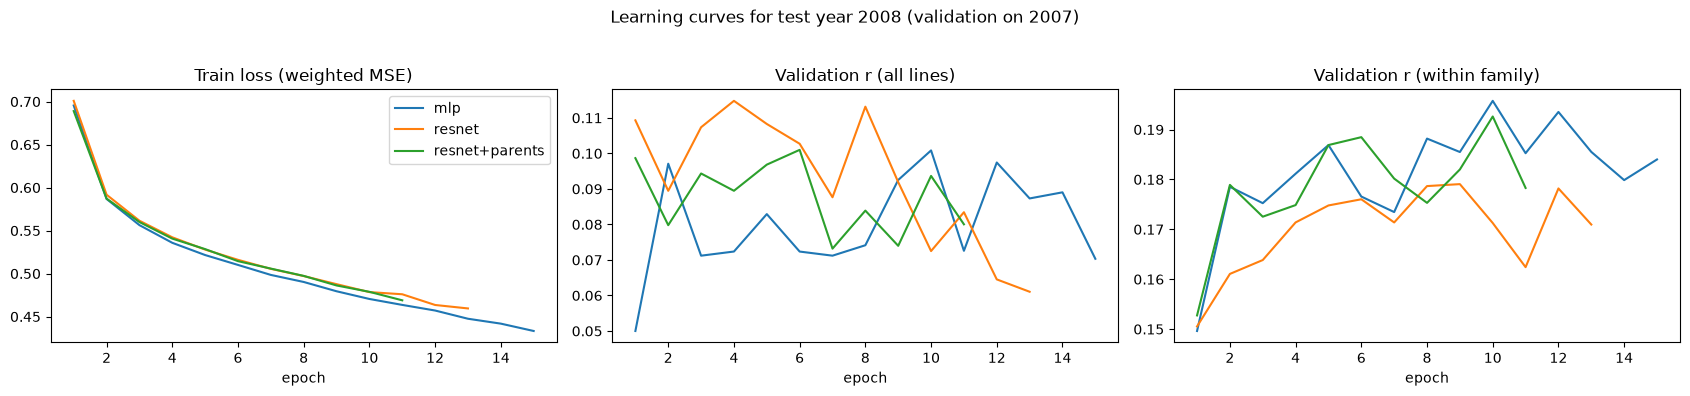

In [7]:
# 1. Learning curves (validation year t-1, models trained on years < t-1)
cy = curves[curves["test_year"] == PLOT_YEAR]
fig, axes = plt.subplots(1, 3, figsize=(17, 3.8))
for name, d in cy.groupby("variant"):
    g = d.groupby("epoch").mean(numeric_only=True)
    axes[0].plot(g.index, g["train_loss"], label=name)
    axes[1].plot(g.index, g["val_r_all"], label=name)
    axes[2].plot(g.index, g["val_r_within"], label=name)
for ax, t in zip(axes, ["Train loss (weighted MSE)", "Validation r (all lines)", "Validation r (within family)"]):
    ax.set_title(t); ax.set_xlabel("epoch")
axes[0].legend()
plt.suptitle(f"Learning curves for test year {PLOT_YEAR} (validation on {PLOT_YEAR - 1})", y=1.03)
plt.tight_layout(); plt.show()

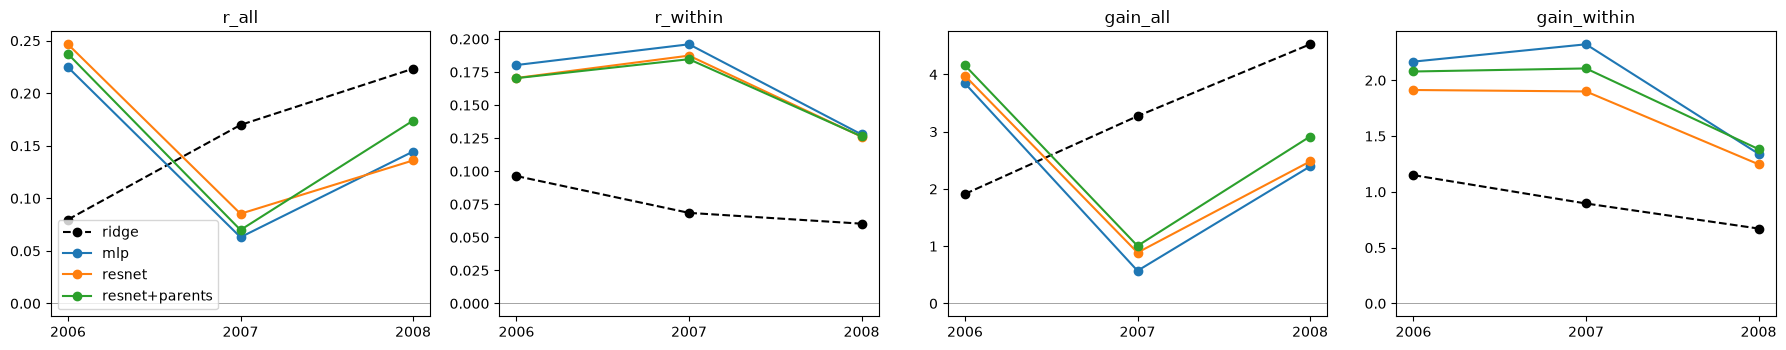

,variant,test_year,n_epochs,r_all,r_within,gain_all,gain_within
0,mlp,2006,2,0.225,0.180,3.844,2.167
1,mlp,2007,8,0.063,0.196,0.571,2.322
2,mlp,2008,2,0.145,0.128,2.393,1.341
3,resnet,2006,2,0.247,0.171,3.976,1.913
4,resnet,2007,7,0.085,0.187,0.888,1.900
5,resnet,2008,5,0.136,0.126,2.480,1.247
6,resnet+parents,2006,2,0.237,0.170,4.158,2.079
7,resnet+parents,2007,2,0.070,0.185,1.006,2.106
8,resnet+parents,2008,5,0.174,0.126,2.916,1.383


In [8]:
# 2. Metrics by year vs ridge (gains rescaled to yield units)
res = results.copy()
for c in ("gain_all", "oracle_gain_all", "gain_within", "oracle_gain_within"):
    res[c] = res[c] * y_sd
ridge = pd.read_csv(DATA_DIR / "ridge_temporal_results.csv")
ridge = ridge[ridge["test_year"].isin(res["test_year"].unique())]

cols = ["r_all", "r_within", "gain_all", "gain_within"]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, m in zip(axes, cols):
    ax.plot(ridge["test_year"], ridge[m], "k--o", label="ridge")
    for name, d in res.groupby("variant"):
        ax.plot(d["test_year"], d[m], "o-", label=name)
    ax.set_title(m); ax.axhline(0, color="gray", lw=0.5)
    ax.set_xticks(sorted(res["test_year"].unique()))
axes[0].legend()
plt.tight_layout(); plt.show()

res.to_csv(DATA_DIR / "mlp_v2_results.csv", index=False)
res[["variant", "test_year", "n_epochs"] + cols].round(3)

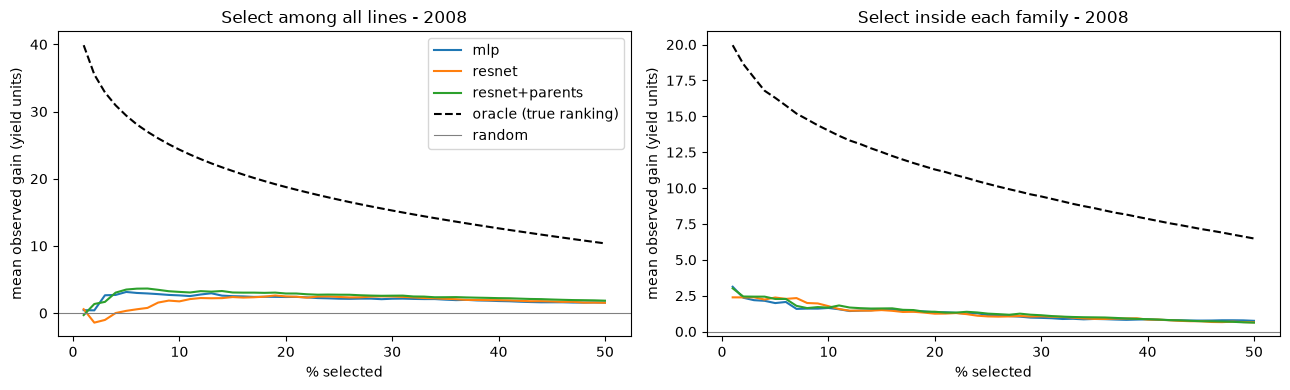

In [9]:
# 3. Selection response curve: observed gain of the top x% vs the year mean
fracs = np.linspace(0.01, 0.5, 50)

def gain_curve(d, score, within):
    out = []
    for f in fracs:
        if within:
            gs, ns = [], []
            for _, g in d.groupby("POP"):
                if len(g) < 20:
                    continue
                k = max(1, int(round(len(g) * f)))
                gs.append(g["BLUE"].iloc[np.argsort(-g[score].to_numpy())[:k]].mean() - g["BLUE"].mean())
                ns.append(len(g))
            out.append(np.average(gs, weights=ns))
        else:
            k = max(1, int(round(len(d) * f)))
            out.append(d["BLUE"].iloc[np.argsort(-d[score].to_numpy())[:k]].mean() - d["BLUE"].mean())
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, within, title in zip(axes, [False, True], ["Select among all lines", "Select inside each family"]):
    for name in VARIANTS:
        ax.plot(fracs * 100, gain_curve(preds[name][PLOT_YEAR], "pred", within), label=name)
    d0 = next(iter(preds.values()))[PLOT_YEAR]
    ax.plot(fracs * 100, gain_curve(d0, "y", within), "k--", label="oracle (true ranking)")
    ax.axhline(0, color="gray", lw=0.8, label="random")
    ax.set_title(f"{title} - {PLOT_YEAR}"); ax.set_xlabel("% selected"); ax.set_ylabel("mean observed gain (yield units)")
axes[0].legend()
plt.tight_layout(); plt.show()

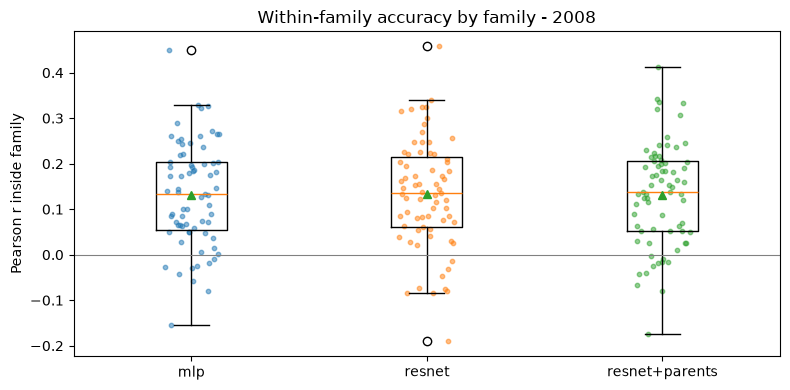

{'mlp': 'mean 0.132, 87% of families > 0', 'resnet': 'mean 0.133, 87% of families > 0', 'resnet+parents': 'mean 0.132, 85% of families > 0'}


In [10]:
# 4. Correlation inside each family (families with >= 20 lines)
def within_r(d):
    return np.array([pearson(g["pred"].to_numpy(), g["y"].to_numpy().astype(float))
                     for _, g in d.groupby("POP") if len(g) >= 20])

fig, ax = plt.subplots(figsize=(8, 4))
data = [within_r(preds[n][PLOT_YEAR]) for n in VARIANTS]
data = [x[~np.isnan(x)] for x in data]
ax.boxplot(data, showmeans=True)
ax.set_xticks(range(1, len(VARIANTS) + 1))
ax.set_xticklabels(list(VARIANTS))
for i, x in enumerate(data, 1):
    ax.scatter(np.full(len(x), i) + np.random.uniform(-0.12, 0.12, len(x)), x, s=10, alpha=0.5)
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("Pearson r inside family"); ax.set_title(f"Within-family accuracy by family - {PLOT_YEAR}")
plt.tight_layout(); plt.show()
print({n: f"mean {x.mean():.3f}, {np.mean(x > 0):.0%} of families > 0" for n, x in zip(VARIANTS, data)})

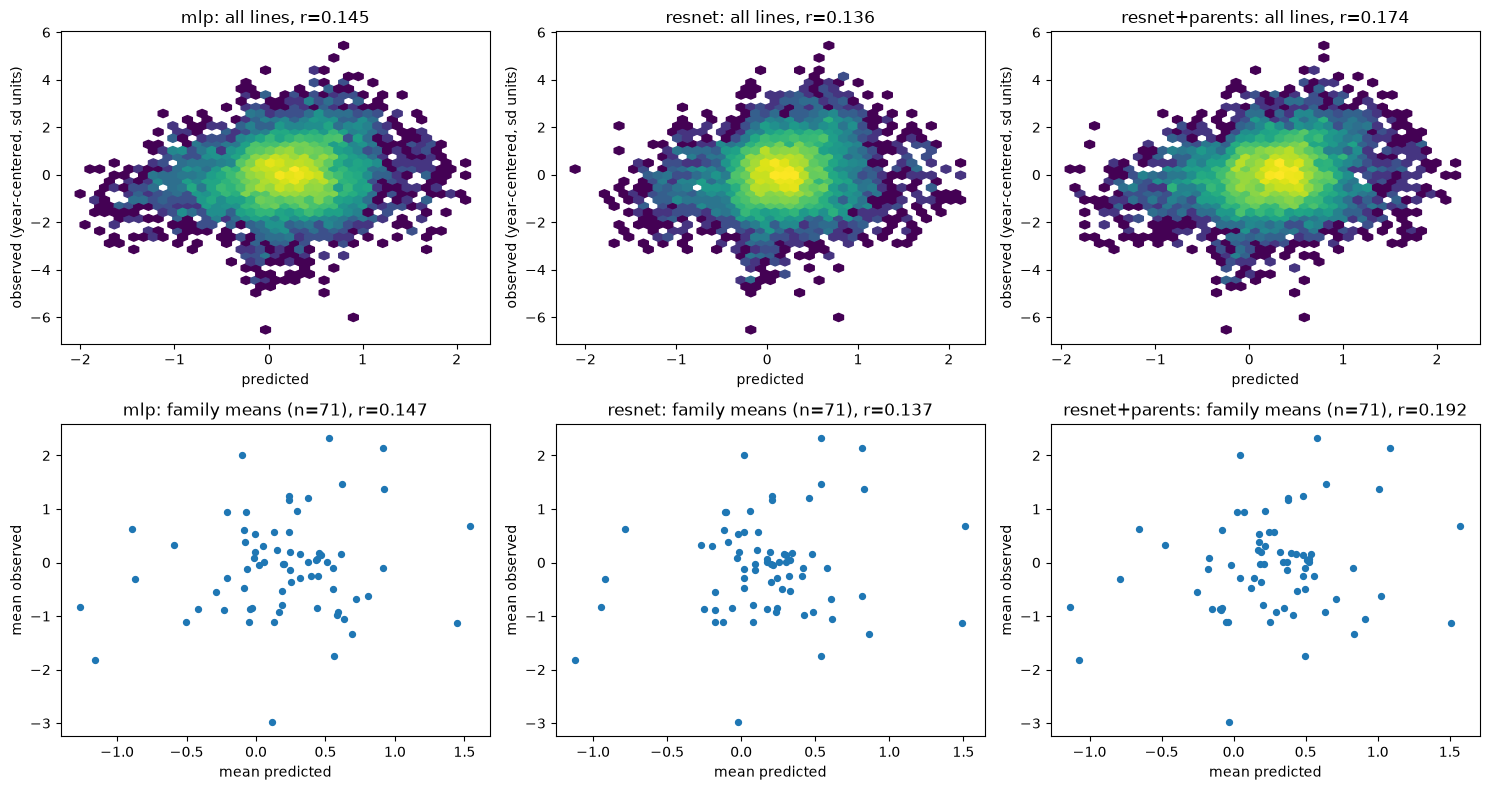

In [11]:
# 5. Predicted vs observed (all lines) and family means (between-family accuracy)
fig, axes = plt.subplots(2, len(VARIANTS), figsize=(5 * len(VARIANTS), 8), squeeze=False)
for j, name in enumerate(VARIANTS):
    d = preds[name][PLOT_YEAR]
    axes[0, j].hexbin(d["pred"], d["y"], gridsize=40, bins="log", cmap="viridis")
    axes[0, j].set_title(f"{name}: all lines, r={pearson(d['pred'].to_numpy(), d['y'].to_numpy().astype(float)):.3f}")
    axes[0, j].set_xlabel("predicted"); axes[0, j].set_ylabel("observed (year-centered, sd units)")
    fm = d.groupby("POP")[["pred", "y"]].mean()
    axes[1, j].scatter(fm["pred"], fm["y"], s=18)
    axes[1, j].set_title(f"{name}: family means (n={len(fm)}), r={pearson(fm['pred'].to_numpy(), fm['y'].to_numpy().astype(float)):.3f}")
    axes[1, j].set_xlabel("mean predicted"); axes[1, j].set_ylabel("mean observed")
plt.tight_layout(); plt.show()

In [12]:
# Top 20% summary and export of predictions for the last test year
wide = None
for name in VARIANTS:
    d = preds[name][PLOT_YEAR].rename(columns={"pred": f"pred_{name}"})
    wide = d if wide is None else wide.merge(d[["LINE_ID", f"pred_{name}"]], on="LINE_ID")
k = int(round(len(wide) * 0.20))
print(f"Year {PLOT_YEAR}: all lines {wide['BLUE'].mean():.2f} | true top 20% {wide.nlargest(k, 'BLUE')['BLUE'].mean():.2f}")
for name in VARIANTS:
    print(f"  {name:16s} top 20% predicted: {wide.nlargest(k, f'pred_{name}')['BLUE'].mean():.2f}")
wide.to_csv(DATA_DIR / f"mlp_v2_predictions_{PLOT_YEAR}.csv", index=False)

Year 2008: all lines 206.16 | true top 20% 224.92
  mlp              top 20% predicted: 208.55
  resnet           top 20% predicted: 208.64
  resnet+parents   top 20% predicted: 209.07
